In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns

h5ad_file = "/home/catherine/phd/projects/termites/data/znev/combined_no_norm_clustered.h5ad"
adata = sc.read_h5ad(h5ad_file)

cell_type_annot_col = 'paper_cell_type_annotation'



In [20]:
#JH Genes
# getting juvenile hormone stuff from Terrapon et al. (2014) reported gene sequences involved in the JH biosynthesis pathways, and the following 13 genes were obtained from the database (http://termitegenome.org/): 
# acetoacetyl-CoA thiolase (AcoAT) (Gene ID: Znev_06783), 
# 3-hydroxy-3-methylglutaryl-CoA synthase 1 and 2 (HMGS1, 2) (Znev_08283 and 14140), 3-hydroxy-3-
# 
# hylglutaryl-CoA reductase (HMGR) (Znev_02974), mevalonate kinase (MK) (Znev_14029), 
# phosphomevalonate kinase (PK) (Znev_12655), diphosphomevalonate decarboxylase (DD) (Znev_08133), isopentenyl diphosphate isomerase (IPPI) (Znev_09747), 
# farnesyl pyrophosphate synthase (FPS) (Znev_02161), 
# farnesal dehydrogenase 1 and 2 (FD1, 2) (Znev_01798 and 03358), 
# JH acid methyltransferase (JHAMT) (Znev_12145) and JH epoxidase (CYP15A1) (Znev_14299).
# pluas According to Terrapon et al. (2014), there was only one CYP15A1 gene in the Z. nevadensis genome (Znev_14299). However, BLAST database searches were performed using the published CYP15A1 genes from other insect species [R. flavipes (Tarver et al. 2012; no. FJ792774), D. punctata (Helvig et al. 2004; no. AY509244) and S. gregaria (Marchal et al. 2011; no. HQ634703)] and found another similar gene sequence in Z. nevadensis (gene ID: Znev_06057). 
with open("/home/catherine/phd/projects/termites/code/znev_analysis/opsin_investigation/caste_gene_diff_analysis/jh_unique_ids.txt", "r") as f:
    jh_list = [line.strip() for line in f]

# add gce
adata.var[adata.var["dmel_gene_symbol"].str.contains("gce", case=False, na=False)]



,gene_ids,feature_types,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,dmel_gene_ortho,dmel_gene_symbol
Znev00002391,Znev00002391,Gene Expression,11764,0.915842,51.49266,22211.0,False,2.151074,2.774317,-0.489073,FBgn0261703,gce


In [21]:
'''gene_display_names = {
    'Znev00000780': '3-hydroxy-3-methylglutaryl-CoA reductase (HMGR)',
    'Znev00004071': '3-hydroxy-3-methylglutaryl-CoA synthase 2(HMGS2)',
    'Znev00004155': 'isopentenyl diphosphate isomerase (IPPI)',
    'Znev00004225': 'JH epoxidase (CYP15A1)',
    'Znev00004645': 'JH epoxidase (CYP15A1)',
    'Znev00004952': 'JH acid methyltransferase (JHAMT)',
    'Znev00005476': '3-hydroxy-3-methylglutaryl-CoA synthase 1 (HMGS1)',
    'Znev00006447': 'mevalonate kinase (MK)',
    'Znev00010869': 'farnesal dehydrogenase 1 (FD1) ',
    'Znev00011682': 'phosphomevalonate kinase (PK)',
    'Znev00011953': 'acetoacetyl-CoA thiolase (AcoAT)',
    'Znev00013778': 'farnesal dehydrogenase 2 (FD2)',
    'Znev00013967': 'farnesyl pyrophosphate synthase (FPS)',
    'Znev00014035': 'diphosphomevalonate decarboxylase (DD)',
    'Znev00002391': 'Germ cell-expressed bHLH-PAS, isoform C (gce)',
}'''

gene_display_names = {
    'Znev00000780': '3-hydroxy-3-methylglutaryl-CoA reductase (HMGR)',
    'Znev00004071': '3-hydroxy-3-methylglutaryl-CoA synthase 2(HMGS2)',
    'Znev00004155': 'isopentenyl diphosphate isomerase (IPPI)',
    'Znev00004645': 'JH epoxidase (CYP15A1)',
    'Znev00004952': 'JH acid methyltransferase (JHAMT)',
    'Znev00005476': '3-hydroxy-3-methylglutaryl-CoA synthase 1 (HMGS1)',
    'Znev00006447': 'mevalonate kinase (MK)',
    'Znev00010869': 'farnesal dehydrogenase 1 (FD1) ',
    'Znev00011682': 'phosphomevalonate kinase (PK)',
    'Znev00011953': 'acetoacetyl-CoA thiolase (AcoAT)',
    'Znev00013778': 'farnesal dehydrogenase 2 (FD2)',
    'Znev00013967': 'farnesyl pyrophosphate synthase (FPS)',
    'Znev00014035': 'diphosphomevalonate decarboxylase (DD)',
    'Znev00002391': 'Germ cell-expressed bHLH-PAS, isoform C (gce)',
}

Plotting for caste: soldier


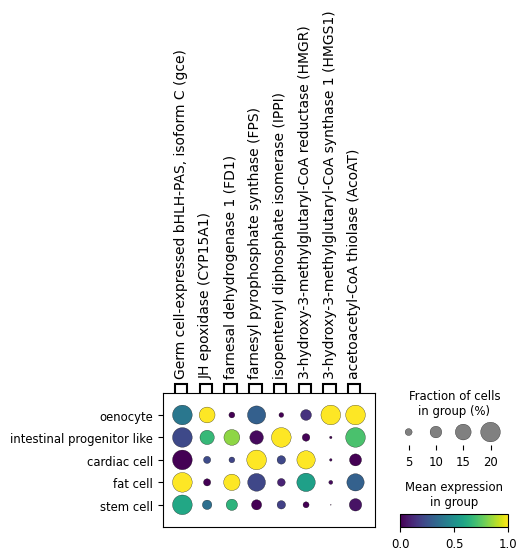

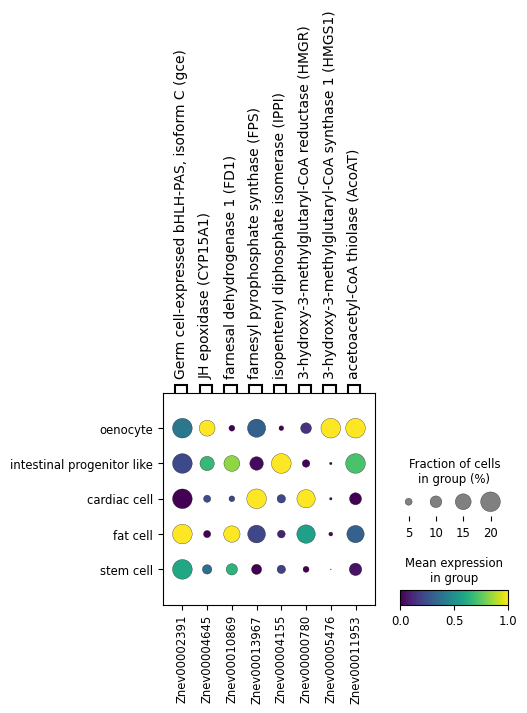

Plotting for caste: worker


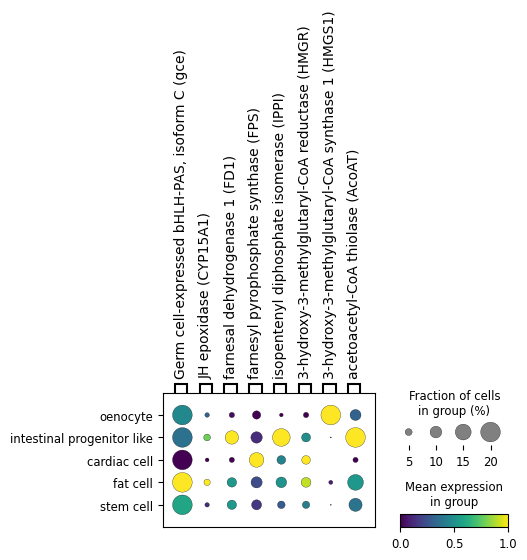

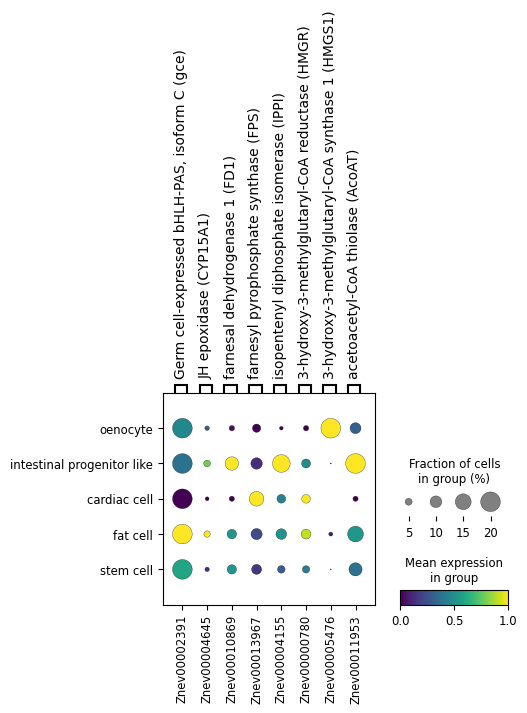

Plotting for caste: king


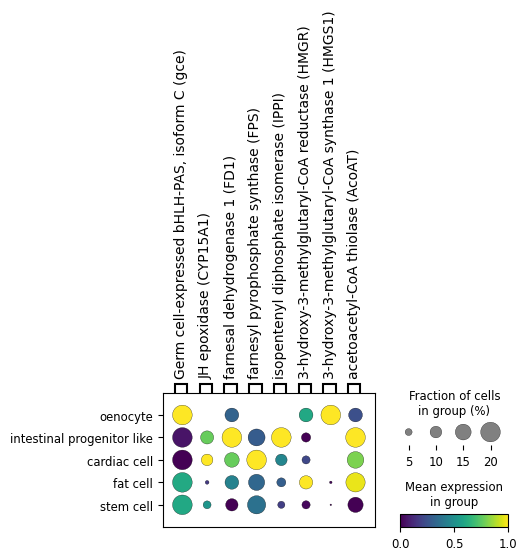

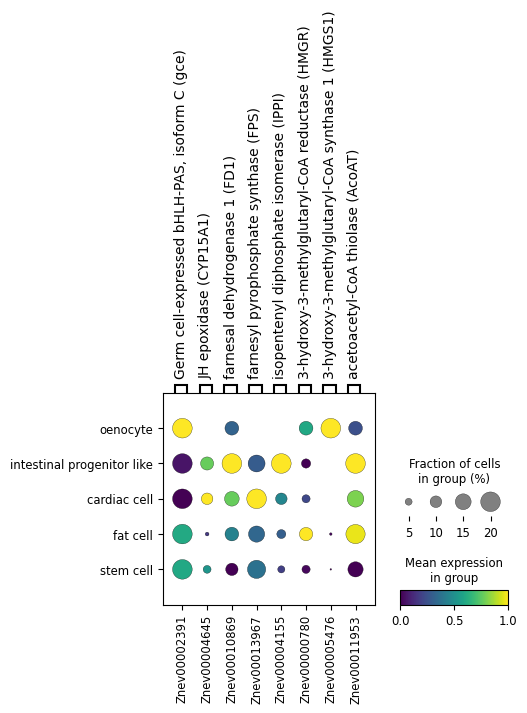

Plotting for caste: queen


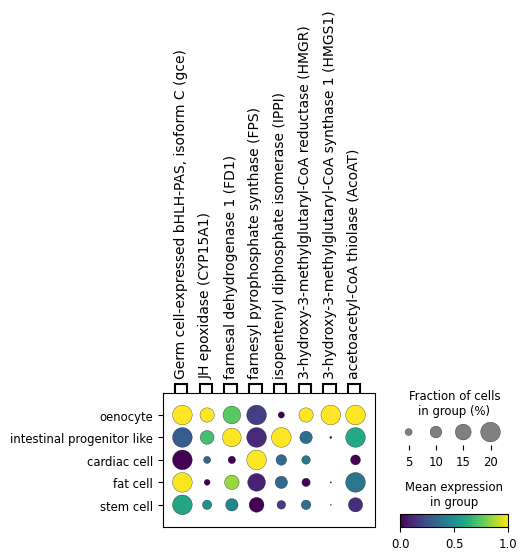

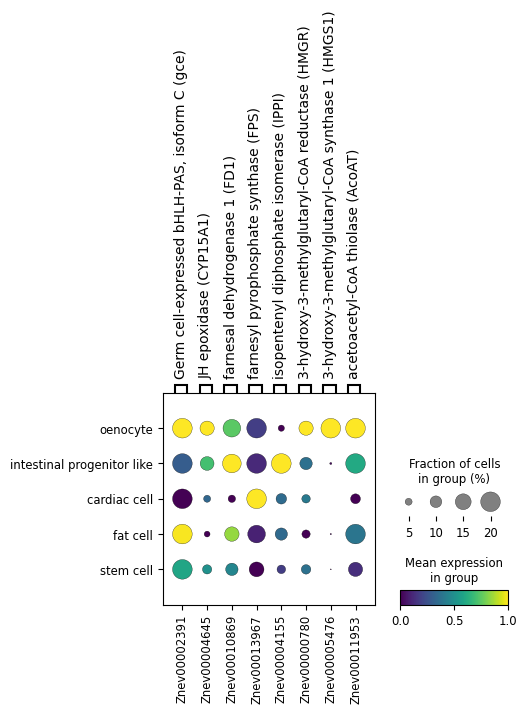

In [22]:
## Figure 4A

new_order = [
    "AcoAT", "HMGS1", "HMGR", 
    "IPPI", "(FPS)", "(FD1)", "CYP15A1", "gce",
]

new_order = new_order[::-1]

tmp = []
for stub in new_order:
    for gene_id, descr in gene_display_names.items():
        if stub in descr:
            tmp.append(gene_id)
            
jh_list = [g for g in tmp if g in adata.var_names]

# flattened list of genes (gene IDs, not the display labels)
flattened_genes = jh_list

from collections import defaultdict

group_to_genes = defaultdict(list)
for idx, gene in enumerate(flattened_genes):
    label = gene_display_names.get(gene, "Other")
    group_to_genes[label].append(idx)

var_group_labels = list(group_to_genes.keys())
var_group_positions = [(min(idxs), max(idxs)) for idxs in group_to_genes.values()]

cell_type_col = "paper_cell_type_annotation"
two_castes = ["soldier", "worker", "king", "queen"]

chosen_cell_types = [
    'oenocyte',
    'intestinal progenitor like',
    'cardiac cell',
    'fat cell',
    'stem cell'
]

adata_all = adata.copy()

# make the groupby column ordered categorical to control y-axis ordering
adata_all.obs[cell_type_col] = pd.Categorical(
    adata_all.obs[cell_type_col],
    categories=chosen_cell_types,
    ordered=True
)

for caste in two_castes:
    print(f"Plotting for caste: {caste}")
    
    ad = adata_all[adata_all.obs["caste"] == caste].copy()
    
    ad.obs[cell_type_col] = pd.Categorical(
        ad.obs[cell_type_col],
        categories=chosen_cell_types,
        ordered=True
    )
    
    dp = sc.pl.dotplot(
        ad,
        var_names=flattened_genes,
        groupby=cell_type_col,
        categories_order=chosen_cell_types,
        standard_scale='var',
        color_map="viridis",
        dot_max=0.2,
        var_group_positions=var_group_positions,
        var_group_labels=var_group_labels,
        show=False,
        return_fig=True,
        title="",
        swap_axes=False
    )

    ax_dict = dp.get_axes()

    # --- Turn off Znev gene ID labels (x-axis) ---
    if "mainplot_ax" in ax_dict:
        ax_dict["mainplot_ax"].set_xticklabels([])
        ax_dict["mainplot_ax"].tick_params(axis="x", length=0)

    # --- Make legend font size bigger ---
    if "group_legend_ax" in ax_dict:
        ax_dict["group_legend_ax"].tick_params(labelsize=18)

    if "colorbar_ax" in ax_dict:
        ax_dict["colorbar_ax"].tick_params(labelsize=14)
        ax_dict["colorbar_ax"].set_ylabel(
            ax_dict["colorbar_ax"].get_ylabel(),
            fontsize=14
        )
    dp.fig.savefig(f"plots/{caste}_4a.png", dpi=600, bbox_inches="tight")

    dp.show()

In [26]:
gene_display_names = {
    'Znev00000780': '3-hydroxy-3-methylglutaryl-CoA reductase (HMGR)',
    'Znev00004071': '3-hydroxy-3-methylglutaryl-CoA synthase 2(HMGS2)',
    'Znev00004155': 'isopentenyl diphosphate isomerase (IPPI)',
    'Znev00004225': 'JH epoxidase (CYP15A1)',
    'Znev00004645': 'JH epoxidase (CYP15A1)',
    'Znev00004952': 'JH acid methyltransferase (JHAMT)',
    'Znev00005476': '3-hydroxy-3-methylglutaryl-CoA synthase 1 (HMGS1)',
    'Znev00006447': 'mevalonate kinase (MK)',
    'Znev00010869': 'farnesal dehydrogenase 1 (FD1) ',
    'Znev00011682': 'phosphomevalonate kinase (PK)',
    'Znev00011953': 'acetoacetyl-CoA thiolase (AcoAT)',
    'Znev00013778': 'farnesal dehydrogenase 2 (FD2)',
    'Znev00013967': 'farnesyl pyrophosphate synthase (FPS)',
    'Znev00014035': 'diphosphomevalonate decarboxylase (DD)',
    'Znev00002391': 'Germ cell-expressed bHLH-PAS, isoform C (gce)',
}

Plotting for caste: queen


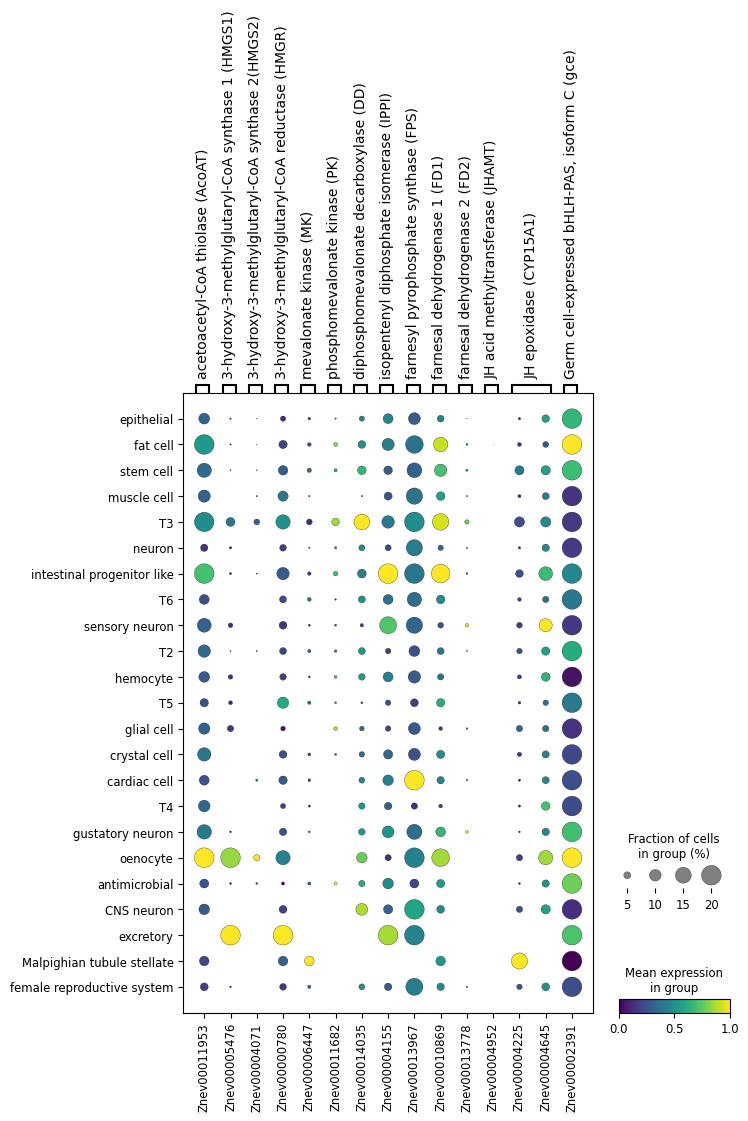

Plotting for caste: king


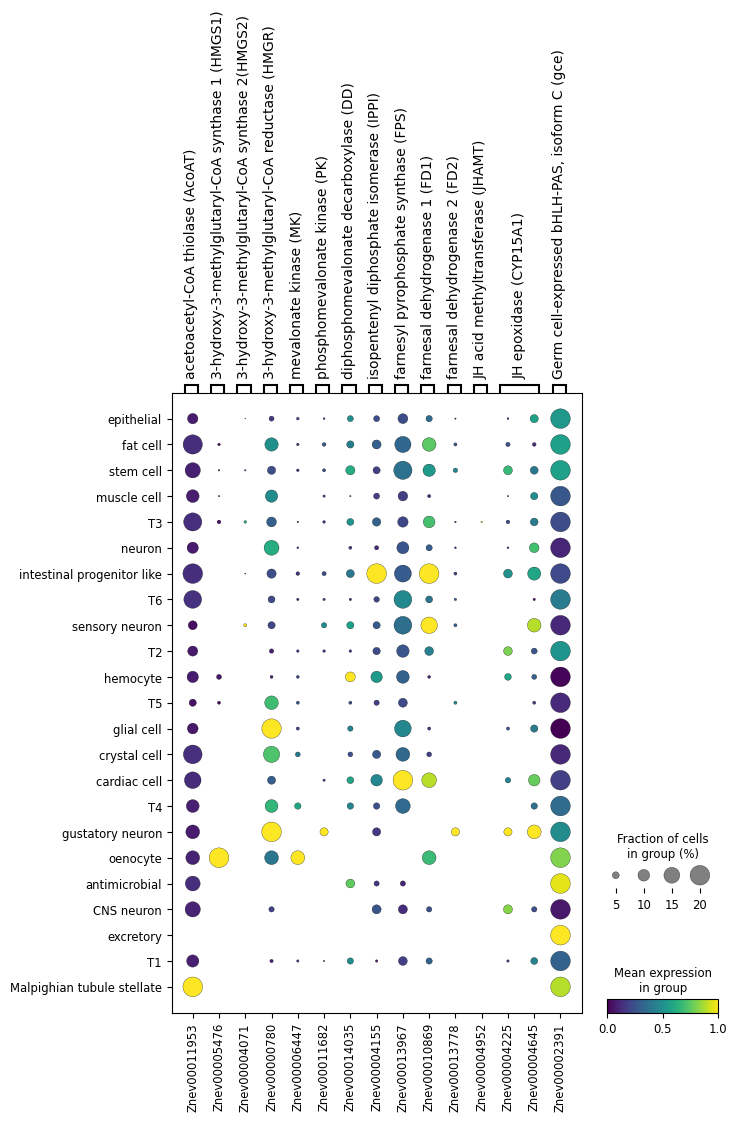

Plotting for caste: soldier


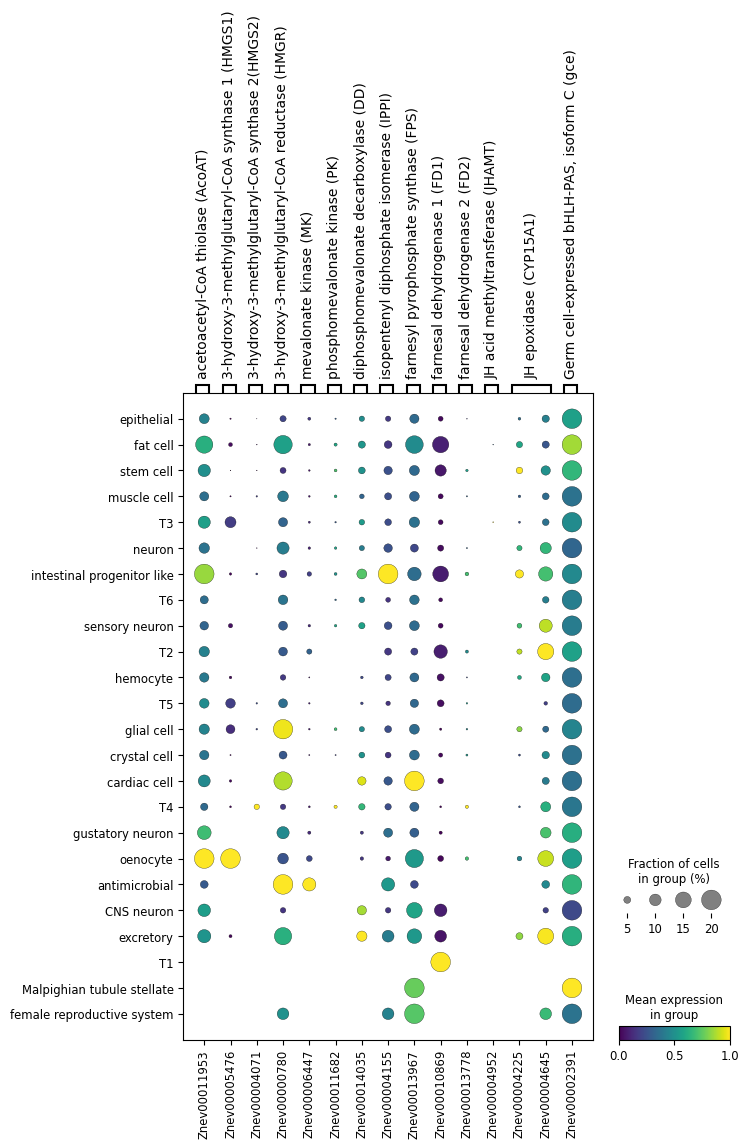

Plotting for caste: worker


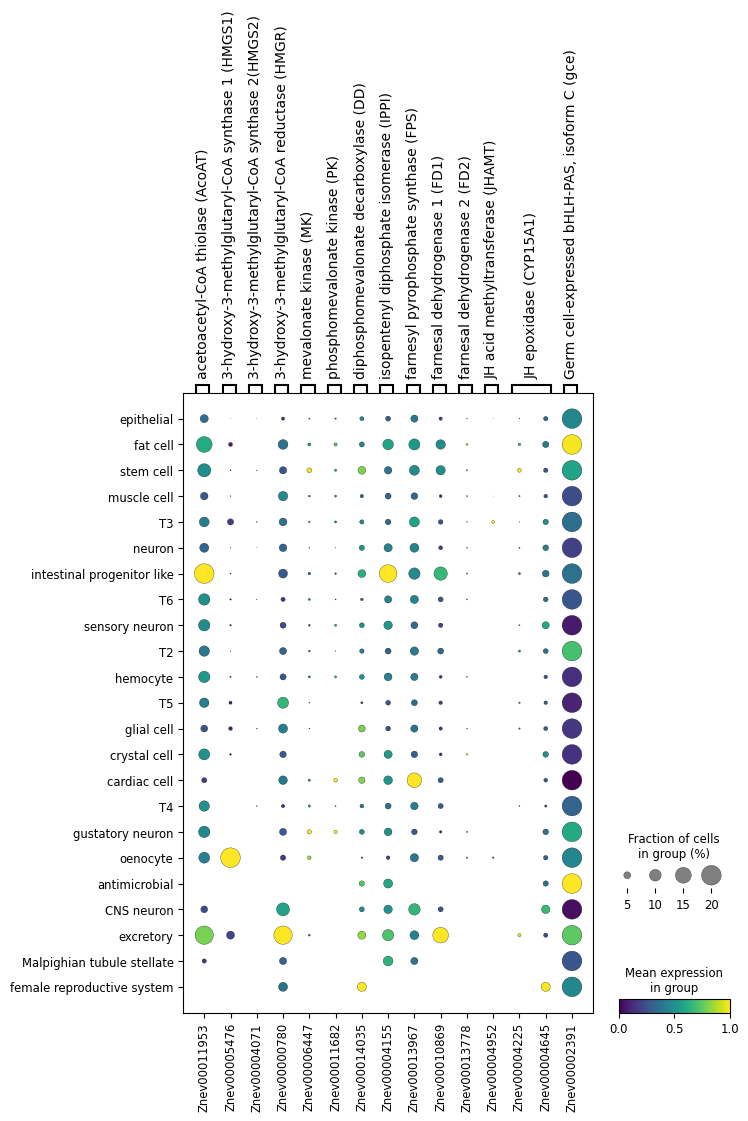

In [27]:
# Keep only genes in the list and in adata
new_order = [
    "AcoAT", "HMGS1", "HMGS2", "HMGR", "(MK)", "(PK)", "(DD)", "IPPI", "(FPS)", "(FD1)", "(FD2)", "JHAMT", "CYP15A1", 'gce',
]
tmp = []
for stub in new_order:
    for gene2, descr in gene_display_names.items():
        if stub in descr:
            tmp.append(gene2)
            continue
jh_list = tmp
jh_list = [g for g in jh_list if g in adata.var_names]

# Flattened list of genes
flattened_genes = jh_list

# Grouping logic: build list of indices for each group
from collections import defaultdict
group_to_genes = defaultdict(list)
for idx, gene in enumerate(flattened_genes):
    label = gene_display_names.get(gene, 'Other')
    group_to_genes[label].append(idx)

# Get var_group_positions and labels
var_group_labels = list(group_to_genes.keys())
var_group_positions = [(min(idxs), max(idxs)) for idxs in group_to_genes.values()]

# Caste loop with top group labels
castes = ['queen', 'king', 'soldier', 'worker']

for caste in castes:
    print(f"Plotting for caste: {caste}")
    adata_caste = adata[adata.obs['caste'] == caste].copy()

    sc.pl.dotplot(
        adata_caste,
        var_names=flattened_genes,
        groupby='paper_cell_type_annotation',
        standard_scale='var',
        dot_max=0.2,
        color_map='viridis',
        var_group_positions=var_group_positions,
        var_group_labels=var_group_labels,
        show=True,
        title='',
    )

/tmp/ipykernel_7803/1542231807.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avgs = mat.groupby([caste_col,cell_type_col]).mean()


Saved table: Table_S7_JH_pathway_worker_vs_castes_wilcoxon.csv


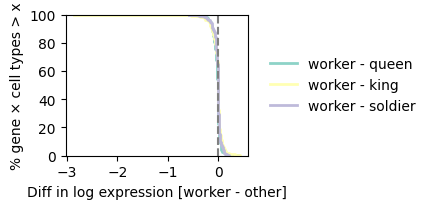

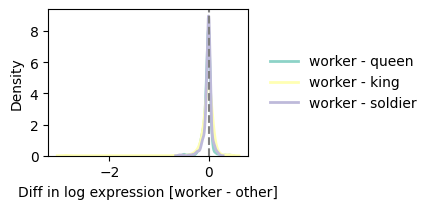

Saved table: Table_S8_gce_worker_vs_castes_wilcoxon.csv


/tmp/ipykernel_7803/1542231807.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avgs = mat.groupby([caste_col,cell_type_col]).mean()


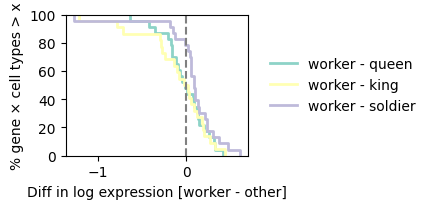

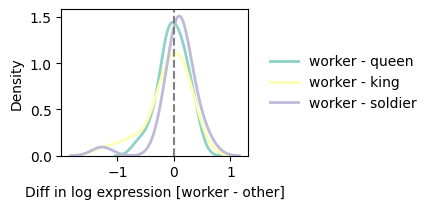

,Gene_set,comparison,n_gene_x_celltype,median_worker_minus_other,p_value,expression
0,Table_S7_JH_pathway,worker_vs_queen,322,-0.0128,0.0,higher in queen
1,Table_S7_JH_pathway,worker_vs_king,308,0.0000,0.0,higher in king
2,Table_S7_JH_pathway,worker_vs_soldier,322,0.0000,0.0,higher in soldier


,Gene_set,comparison,n_gene_x_celltype,median_worker_minus_other,p_value,expression
0,Table_S8_gce,worker_vs_queen,23,-0.0168,0.85,no difference
1,Table_S8_gce,worker_vs_king,22,-0.0023,0.52,no difference
2,Table_S8_gce,worker_vs_soldier,23,0.0922,0.02,higher in worker


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# ---------------------------------------------------
# Gene sets
# ---------------------------------------------------

gce_gene = ["Znev00002391"]

jh_pathway = [
    'Znev00000780','Znev00004071','Znev00004155','Znev00004645',
    'Znev00004952','Znev00005476','Znev00006447','Znev00010869',
    'Znev00011682','Znev00011953','Znev00013778','Znev00013967',
    'Znev00014035','Znev00004225'
]

gene_sets = {
    "JH_pathway": jh_pathway,
    "gce_only": gce_gene
}

# ---------------------------------------------------
# Metadata
# ---------------------------------------------------

cell_type_col = "paper_cell_type_annotation"
caste_col = "caste"

chosen_castes = ["worker","queen","king","soldier"]

reference = "worker"
others = ["queen","king","soldier"]

alpha = 0.05

palette = sns.color_palette("Set3",4)
palette_dict = {
    "worker":palette[3],
    "soldier":palette[2],
    "king":palette[1],
    "queen":palette[0]
}

# ---------------------------------------------------
# Analysis function
# ---------------------------------------------------

def run_analysis(gene_list, label):

    genes = [g for g in gene_list if g in adata.var_names]

    adata_sub = adata[
        adata.obs[caste_col].isin(chosen_castes),
        genes
    ].copy()

    X = adata_sub.X
    if hasattr(X,"toarray"):
        X = X.toarray()

    mat = pd.DataFrame(X,columns=adata_sub.var_names)
    mat[cell_type_col] = adata_sub.obs[cell_type_col].values
    mat[caste_col] = adata_sub.obs[caste_col].values

    avgs = mat.groupby([caste_col,cell_type_col]).mean()

    results = []
    stats_dict = {}

    for c in others:

        pooled_diffs = []

        for gene in genes:

            tmp = avgs[gene].unstack(level=0)

            if reference not in tmp.columns or c not in tmp.columns:
                continue

            diff = (tmp[reference] - tmp[c]).dropna()
            diff = diff[np.isfinite(diff.values)].values

            pooled_diffs.extend(diff)

        pooled_diffs = np.asarray(pooled_diffs,float)

        if pooled_diffs.size == 0:
            continue

        stats_dict[c] = pooled_diffs

        med = float(np.median(pooled_diffs))

        try:
            p = wilcoxon(pooled_diffs,alternative="two-sided").pvalue
        except:
            p = np.nan

        if np.isnan(p):
            expr = "NA"
        elif p >= alpha:
            expr = "no difference"
        else:
            expr = "higher in worker" if med > 0 else f"higher in {c}"

        results.append({
            "Gene_set":label,
            "comparison":f"worker_vs_{c}",
            "n_gene_x_celltype":len(pooled_diffs),
            "median_worker_minus_other":round(med,4),
            "p_value":round(p,2) if not np.isnan(p) else "",
            "expression":expr
        })

    df = pd.DataFrame(results)

    # save table
    out_csv = f"{label}_worker_vs_castes_wilcoxon.csv"
    df.to_csv(out_csv,index=False)

    print(f"Saved table: {out_csv}")

    # ---------------------------------------------------
    # ECDF plot
    # ---------------------------------------------------

    fig,ax = plt.subplots(figsize=(4.5,2.2))

    for c in others:

        if c not in stats_dict:
            continue

        ax.ecdf(
            stats_dict[c],
            complementary=True,
            lw=2,
            color=palette_dict[c],
            label=f"{reference} - {c}"
        )

    ax.axvline(0,ls="--",color="grey")

    ax.set_xlabel("Diff in log expression [worker - other]")
    ax.set_ylabel("% gene × cell types > x")

    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6))
    ax.set_yticklabels([f"{int(v*100)}" for v in np.linspace(0,1,6)])

    ax.legend(frameon=False,loc="center left",bbox_to_anchor=(1.05,0.5))

    fig.tight_layout()

    plt.savefig(f"{label}_ECDF.pdf",dpi=600)
    plt.show()


    # ---------------------------------------------------
    # KDE plot
    # ---------------------------------------------------

    fig,ax = plt.subplots(figsize=(4.5,2.2))

    for c in others:

        if c not in stats_dict:
            continue

        sns.kdeplot(
            stats_dict[c],
            ax=ax,
            lw=2,
            color=palette_dict[c],
            label=f"{reference} - {c}"
        )

    ax.axvline(0,ls="--",color="grey")

    ax.set_xlabel("Diff in log expression [worker - other]")
    ax.set_ylabel("Density")

    ax.legend(frameon=False,loc="center left",bbox_to_anchor=(1.05,0.5))

    fig.tight_layout()

    plt.savefig(f"{label}_KDE.pdf",dpi=600)
    plt.show()

    return df


# ---------------------------------------------------
# Run both analyses
# ---------------------------------------------------

df_S7 = run_analysis(jh_pathway,"Table_S7_JH_pathway")
df_S8 = run_analysis(gce_gene,"Table_S8_gce")

display(df_S7)
display(df_S8)

In [31]:
import pandas as pd

gene_display_names = {
    'Znev00000780': '3-hydroxy-3-methylglutaryl-CoA reductase (HMGR)',
    'Znev00004071': '3-hydroxy-3-methylglutaryl-CoA synthase 2 (HMGS2)',
    'Znev00004155': 'isopentenyl diphosphate isomerase (IPPI)',
    'Znev00004225': 'JH epoxidase (CYP15A1)',
    'Znev00004645': 'JH epoxidase (CYP15A1)',
    'Znev00004952': 'JH acid methyltransferase (JHAMT)',
    'Znev00005476': '3-hydroxy-3-methylglutaryl-CoA synthase 1 (HMGS1)',
    'Znev00006447': 'mevalonate kinase (MK)',
    'Znev00010869': 'farnesal dehydrogenase 1 (FD1)',
    'Znev00011682': 'phosphomevalonate kinase (PK)',
    'Znev00011953': 'acetoacetyl-CoA thiolase (AcoAT)',
    'Znev00013778': 'farnesal dehydrogenase 2 (FD2)',
    'Znev00013967': 'farnesyl pyrophosphate synthase (FPS)',
    'Znev00014035': 'diphosphomevalonate decarboxylase (DD)',
    'Znev00002391': 'Germ cell-expressed bHLH-PAS, isoform C (gce)',
}

# Convert to dataframe
df = pd.DataFrame(
    list(gene_display_names.items()),
    columns=["Znev_ID", "JH_Gene"]
)

# Save CSV
out_file = "JH_pathway_genes.csv"
df.to_csv(out_file, index=False)

print(f"Saved: {out_file}")

# Print table for quick copy/paste
print(df)

Saved: JH_pathway_genes.csv
         Znev_ID                                            JH_Gene
0   Znev00000780    3-hydroxy-3-methylglutaryl-CoA reductase (HMGR)
1   Znev00004071  3-hydroxy-3-methylglutaryl-CoA synthase 2 (HMGS2)
2   Znev00004155           isopentenyl diphosphate isomerase (IPPI)
3   Znev00004225                             JH epoxidase (CYP15A1)
4   Znev00004645                             JH epoxidase (CYP15A1)
5   Znev00004952                  JH acid methyltransferase (JHAMT)
6   Znev00005476  3-hydroxy-3-methylglutaryl-CoA synthase 1 (HMGS1)
7   Znev00006447                             mevalonate kinase (MK)
8   Znev00010869                     farnesal dehydrogenase 1 (FD1)
9   Znev00011682                      phosphomevalonate kinase (PK)
10  Znev00011953                   acetoacetyl-CoA thiolase (AcoAT)
11  Znev00013778                     farnesal dehydrogenase 2 (FD2)
12  Znev00013967              farnesyl pyrophosphate synthase (FPS)
13  Znev00014035    